In [107]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import ast
import nltk
import warnings
warnings.filterwarnings('ignore')

In [108]:
df = pd.read_csv('spam.csv', encoding='latin1') 
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [109]:
df.shape

(5572, 5)

In [110]:
# data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [111]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [112]:
df.sample(5)

,v1,v2
1288,ham,Happy new year to u too!
4731,ham,Wat time r Ì_ going to xin's hostel?
4807,ham,What's up my own oga. Left my phone at home an...
2801,ham,And smile for me right now as you go and the w...
1033,ham,"OH MR SHEFFIELD! You wanna play THAT game, oka..."


In [113]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1741,ham,I can do that! I want to please you both insid...
2835,ham,Nice.nice.how is it working?
5403,ham,So gd got free ice cream... I oso wan...
4134,ham,No need to say anything to me. I know i am an ...
4245,ham,Well welp is sort of a semiobscure internet thing


In [114]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [115]:
df['target']=encoder.fit_transform(df['target'])

In [116]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [117]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [118]:
df=df.drop_duplicates(keep='first')

In [119]:
df.duplicated().sum()

np.int64(0)

In [120]:
#EDA__________________________________________

df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

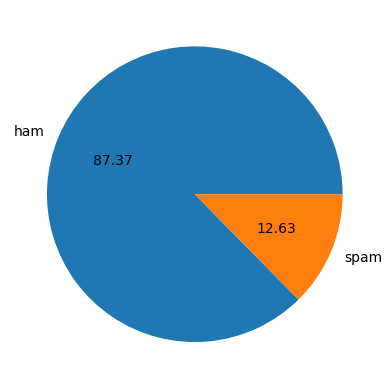

In [121]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [122]:
# data is imbalanced (acc to pie chart)

In [123]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\risha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\risha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [124]:
df['num_characters']=df['text'].apply(len)
# numbers of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [125]:
df[['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [126]:
# ham
df[df['target']==0][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [127]:
# spam
df[df['target']==1][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

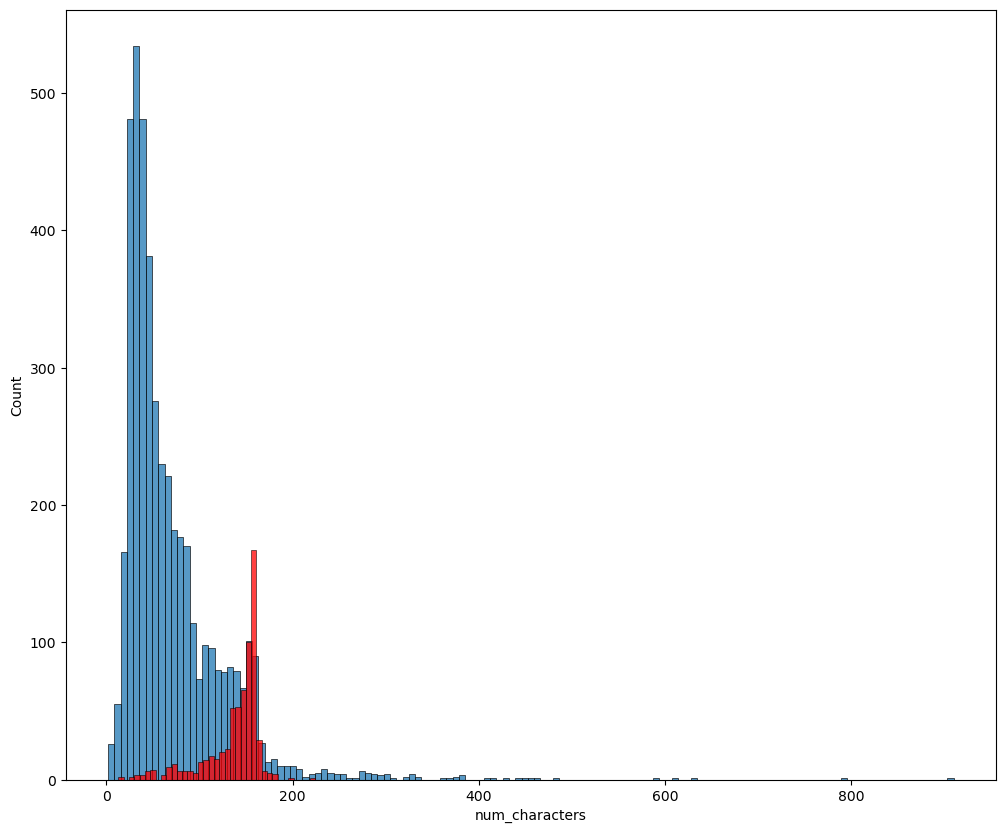

In [128]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

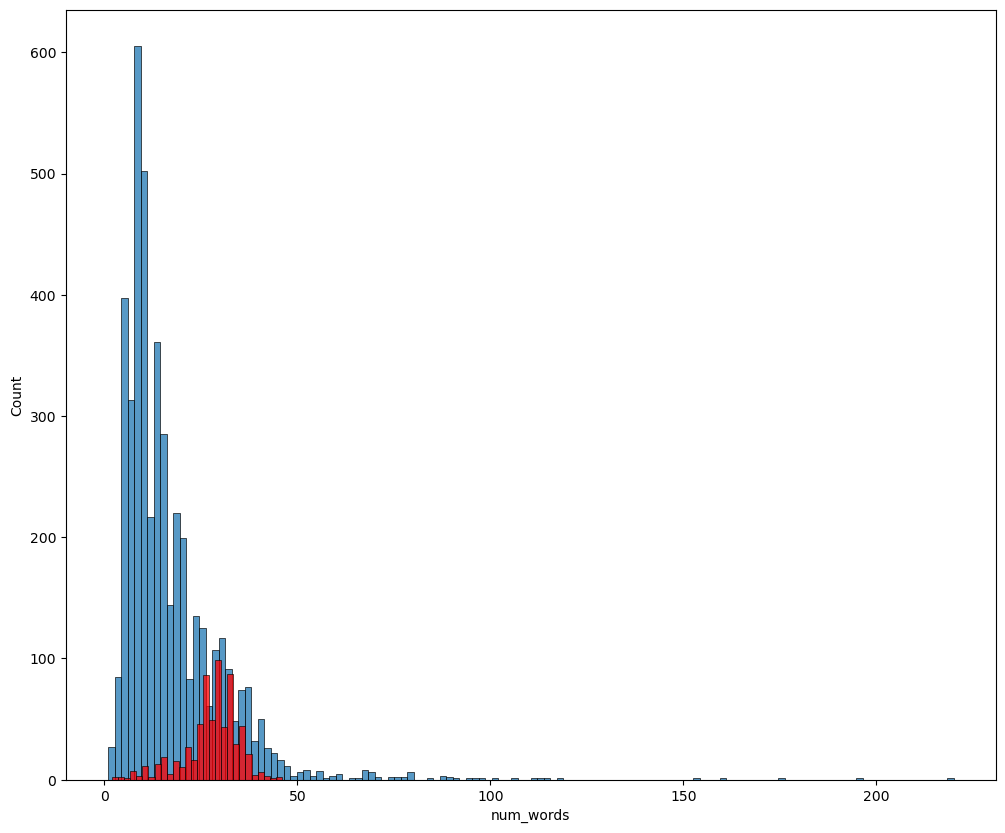

In [129]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

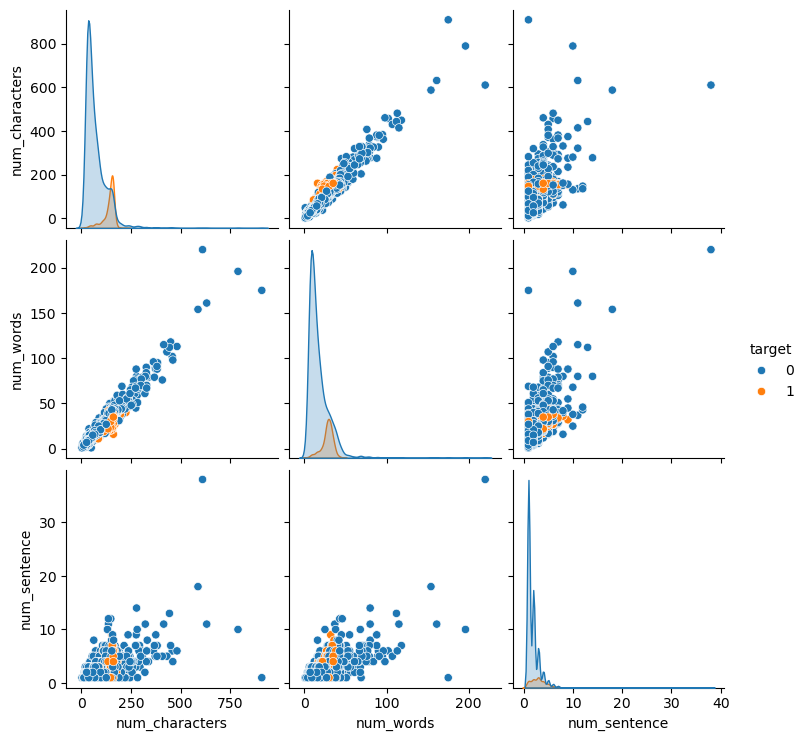

In [130]:
sns.pairplot(df,hue='target')

<Axes: >

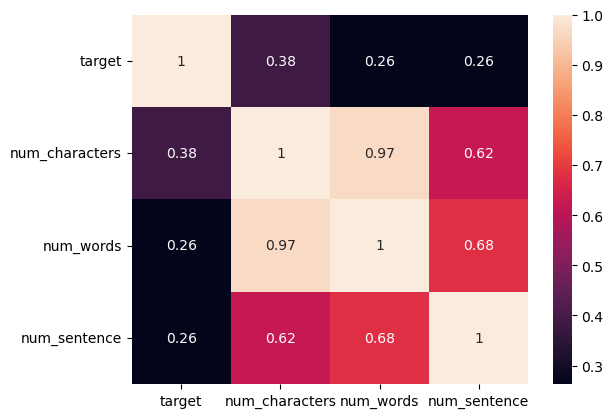

In [131]:

numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Then create the heatmap with only numeric columns
sns.heatmap(numeric_df.corr(), annot=True)

In [132]:
# data preprocessing (can say text preprocessing cause data is textual)
# Lowercase, Tokenization, Removing special characters, Removing stop words and punctuation and stemming(remove similar word to one ex - damce damceer)

In [133]:
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()#steming words in root form

def transform_text(text):
    text = text.lower()#lowercase
    text = nltk.word_tokenize(text)#tokenization
    y=[]
    for i in text: # for special character
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [134]:
transform_text('can we dance like dancing studion ##')#stopword and punctuation are removed

'danc like danc studion'

In [135]:
df['transform_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [136]:
from wordcloud import WordCloud

# Create a WordCloud object with specified parameters
wc = WordCloud(
    width=800,  # Width of the canvas in pixels
    height=400,  # Height of the canvas in pixels
    max_words=200,  # Maximum number of words to include
    background_color='white',  # Background color for the word cloud
    colormap='viridis'  # Color scheme for the words
)

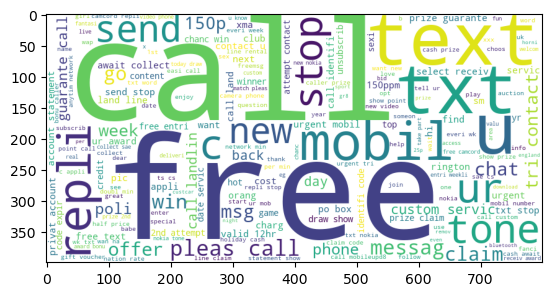

In [137]:
spam_wc = wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

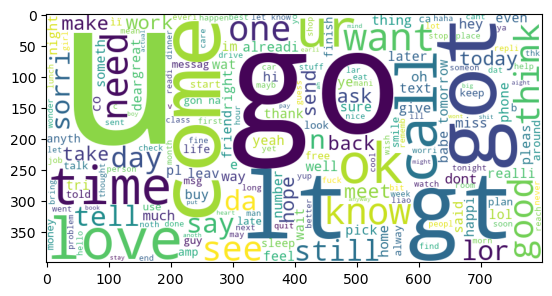

In [138]:
ham_wc = wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [139]:
spam_corpus=[]
for msg in df[df['target']==1]['transform_text'].tolist():
    for words in msg.split():
        spam_corpus.append(words)
        

In [140]:
len(spam_corpus)

9939

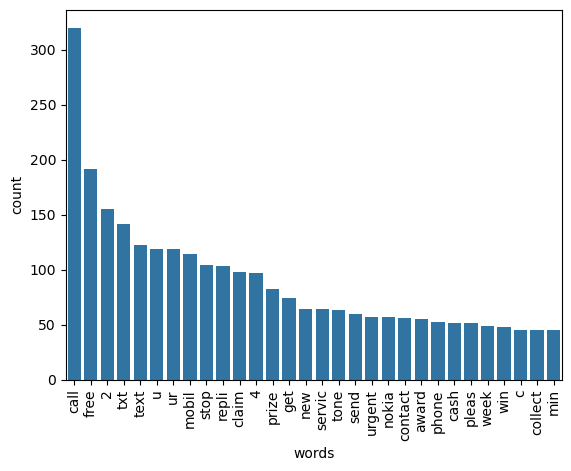

In [142]:
from collections import Counter
most_common_df = pd.DataFrame(Counter(spam_corpus).most_common(30), 
                             columns=['words', 'count'])

# Use named parameters x and y instead of positional arguments
sns.barplot(x='words', y='count', data=most_common_df)
plt.xticks(rotation='vertical')
plt.show()
# from collections import Counter
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
# plt.xticks(rotation='vertical')
# plt.show()

In [143]:
ham_corpus=[]
for msg in df[df['target']==0]['transform_text'].tolist():
    for words in msg.split():
        ham_corpus.append(words)
        

In [144]:
len(ham_corpus)

35404

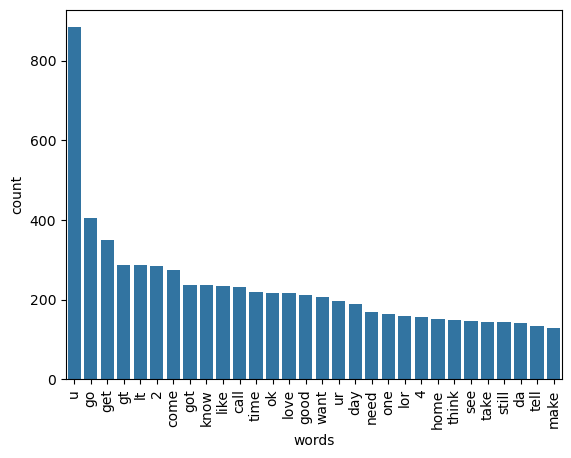

In [145]:
most_common_df_ham = pd.DataFrame(Counter(ham_corpus).most_common(30), 
                             columns=['words', 'count'])

# Use named parameters x and y instead of positional arguments
sns.barplot(x='words', y='count', data=most_common_df_ham)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# model building (naive bayes perform good in contextual data)

In [146]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer() # firs do with this 
tfidf = TfidfVectorizer() # and second do with this

In [147]:
X = tfidf.fit_transform(df['transform_text']).toarray()
X.shape

(5169, 6708)

In [148]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [149]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [150]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score 
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()

In [151]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [152]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [153]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [ ]:
# because precision give better result in mnb then we choose this model to train

In [154]:
# now we train this model to every algo
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [155]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [156]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [157]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

In [158]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8380952380952381
For  LR
Accuracy -  0.9516441005802708
Precision -  0.94
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8409090909090909
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  GBDT
Accuracy -  0.9526112185686654
Precision -  0.9238095238095239
For  xgb
Accuracy -  0.9748549323017408
Precision -  0.9516129032258065


In [161]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)
performance_df
print(performance_df)

   Algorithm  Accuracy  Precision
1         KN  0.900387   1.000000
2         NB  0.959381   1.000000
5         RF  0.971954   1.000000
8        ETC  0.972921   0.982456
0        SVC  0.972921   0.974138
10       xgb  0.974855   0.951613
4         LR  0.951644   0.940000
9       GBDT  0.952611   0.923810
7        BgC  0.958414   0.862595
6   AdaBoost  0.924565   0.840909
3         DT  0.935203   0.838095


In [169]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")# id_vars remain same
performance_df1#pivot the value of accuracy and precision

,Algorithm,variable,value
0,KN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.972921
5,xgb,Accuracy,0.974855
6,LR,Accuracy,0.951644
7,GBDT,Accuracy,0.952611
8,BgC,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


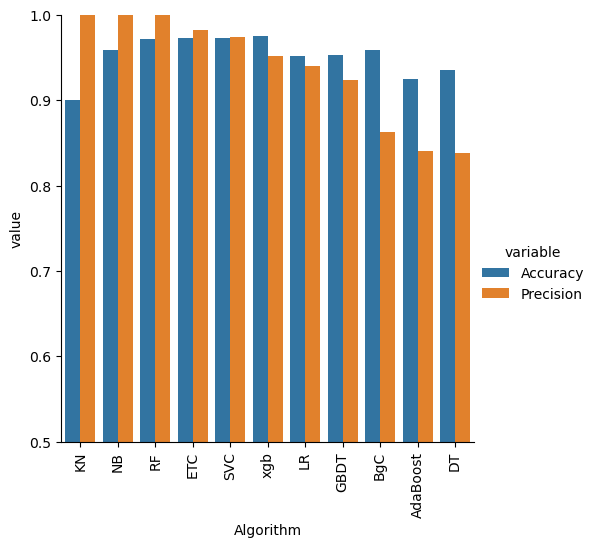

In [170]:
sns.catplot(x = 'Algorithm', y='value', hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
# improve the model performance

In [ ]:
# in upper code when ifidfVectorizer is installed then that time we have to put parameter max_feature (used for train most used variavles)
# check which parameter value work best and keep that
# use minmax scaler in xinput
# use voting classifier (group of best model )
# use stacing classifire (similar to voting classifier stanking the best algo in one and decide final_estimatior = anyalgo)